In [1]:
from dilated_nns_nns import output_dir, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import torch
from conv2d_circular import EquivariantConv2d
import numpy.typing as npt
import numpy as np
from spin_lattices import SquareLattice

Running dilated_nns_xors.py


In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

In [6]:
df.columns

Index(['eps_train', 'n_test', 'hidden_channels', 'dilations', 'epochs', 'runs',
       'write_each_epoch', 'lr', 'batch_size', 'shuffle',
       'n_train_from_full_space', 'sample_repr_then_apply_random_symmetry',
       'sample_with_replacement', 'kernel_size', 'target_kernel_size',
       'target_hidden_channels', 'lattice', 'test_accuracy', 'train_loss',
       'epoch', 'start_timestamp', 'current_timestamp', 'run', 'task_id',
       'n_train'],
      dtype='object')

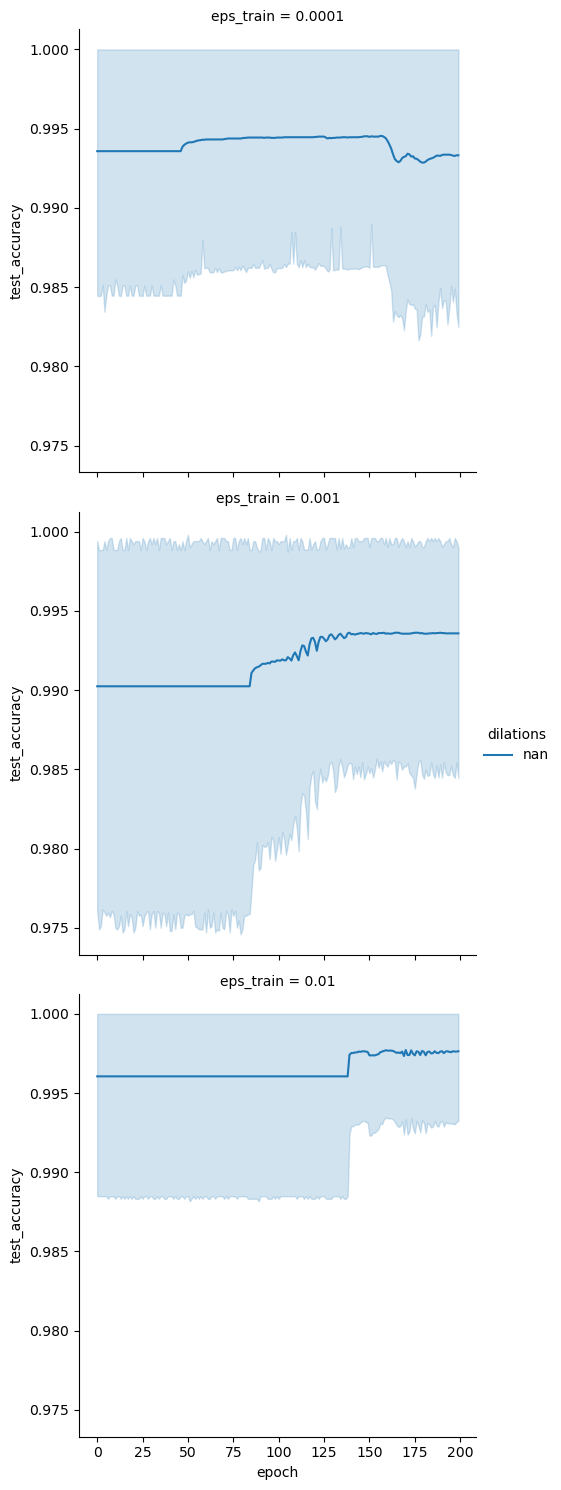

In [9]:
sns.relplot(
    df.pipe(column_to(str, "dilations")).query("kernel_size == 5"),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind="line",
    row="eps_train",
)

In [10]:
sns.relplot(
    df.pipe(column_to(str, "dilations")).query("kernel_size == 3"),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind="line",
    row="eps_train",
)